# Análisis exploratorio

### 1) importaciones, lecturas y merges

In [1]:
import os
import pathlib
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import seaborn as sns
import pandas as pd
import networkx as nx

In [2]:
data_dir = '../Datasets'
files = [f for f in os.listdir(data_dir + "/filtered_data") if f.endswith('.csv') and not f.startswith('triplets')]

# Material de trabajo:
dfs_dict = {file_name: pd.read_csv(os.path.join(data_dir, "filtered_data", file_name)) for file_name in files}
big_df = pd.read_csv(os.path.join(data_dir, "filtered_data",  "triplets.csv"))

# Cargamos los tipos de entidad
folder_entity_types = os.path.join(data_dir, "entity_types_clean")
files_entity_types = os.listdir(folder_entity_types)
roots_entitity_type = [os.path.join(folder_entity_types, file) for file in files_entity_types if file.endswith('.csv')]
entity_types_dfs = {files_entity_types[i].split(".")[0]: pd.read_csv(roots_entitity_type[i]) for i in range(len(roots_entitity_type))}
big_entity_types_df = pd.concat(entity_types_dfs.values(), ignore_index=True)
big_entity_types_df = big_entity_types_df.drop_duplicates(subset=['entidad', 'tipo_entidad'])

# Cruzamos los tipos de entidades con las tripletas
merged_df = big_df.merge(
    big_entity_types_df,
    left_on='entidad',
    right_on='entidad',
    how='left'
)

# Para cada dataframe individual lo cruzamos para tener los tipos de entidad
full_dfs_dict = {}
for file_name, df in dfs_dict.items():
    merged_individual_df = df.merge(
        entity_types_dfs[file_name.split(".")[0]],
        left_on='entidad',
        right_on='entidad',
        how='left'
    )
    full_dfs_dict[file_name.split(".")[0]] = merged_individual_df
# rename dict key 'republica_dominicana.csv' as rep_dominicana
full_dfs_dict['rep_dominicana'] = full_dfs_dict.pop('republica_dominicana')

# Separamos los dataframes por país y tipo de entidad
personajes_por_pais = {name: df[df['tipo_entidad'] == "ser humano".strip()] for name, df in full_dfs_dict.items()}
objetos_por_pais = {name: df[df['tipo_entidad'] != "ser humano".strip()] for name, df in full_dfs_dict.items()}


### 1) Personajes y objetos por país

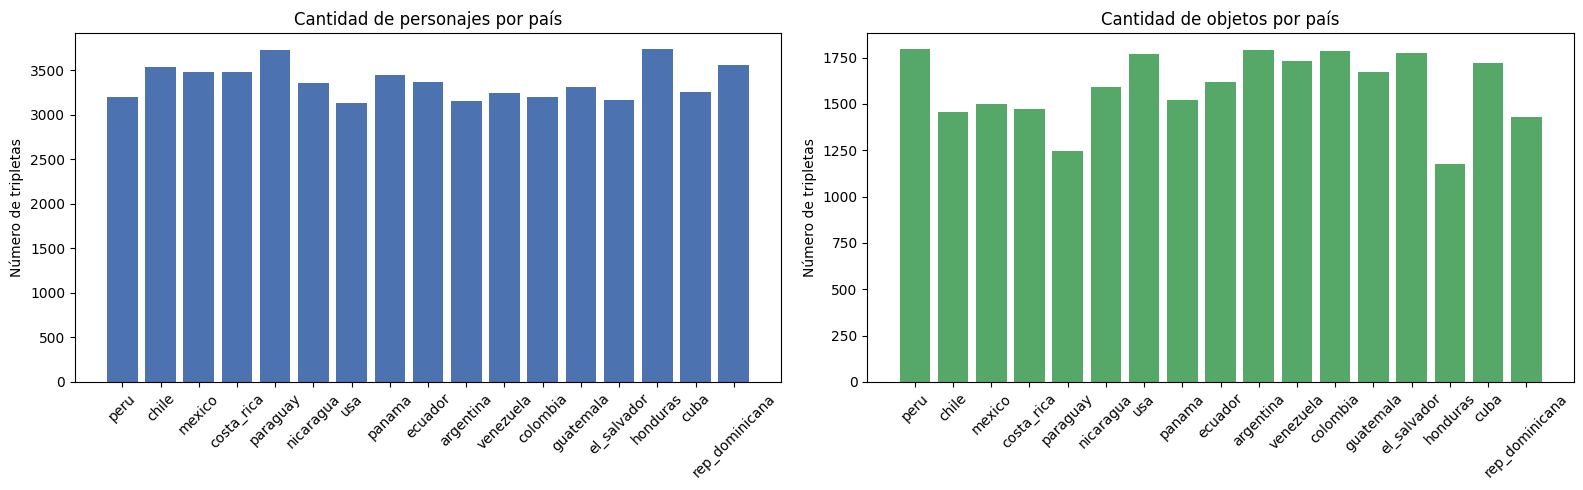

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(personajes_por_pais.keys(),
            [len(df) for df in personajes_por_pais.values()],
            color="#4C72B0")
axes[0].set_title("Cantidad de personajes por país")
axes[0].set_ylabel("Número de tripletas")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(objetos_por_pais.keys(),
            [len(df) for df in objetos_por_pais.values()],
            color="#55A868")
axes[1].set_title("Cantidad de objetos por país")
axes[1].set_ylabel("Número de tripletas")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2) Relaciones más frecuentes para entidades (personas y objetos)

In [4]:
def plot_relations(data, top_n=20, title_suffix='ser humano'):
    plt.figure(figsize=(16, 9))
    sns.barplot(
        data=data.head(top_n),
        y='relacion',
        x='count',
        hue='relacion',
        palette='viridis',
        legend=False
    )
    plt.xlabel('Frecuencia')
    plt.ylabel('Relación')
    plt.title(f'Top {top_n} relaciones más frecuentes para {title_suffix}')
    plt.tight_layout()
    plt.show()

In [5]:
merged_df.head(2)

,entidad,relacion,objeto,source_file,tipo_entidad
0,Ariel Fernández,Lugar de nacimiento,Bahía Blanca,argentina,ser humano
1,Ariel Fernández,Ocupación,biofísico,argentina,ser humano


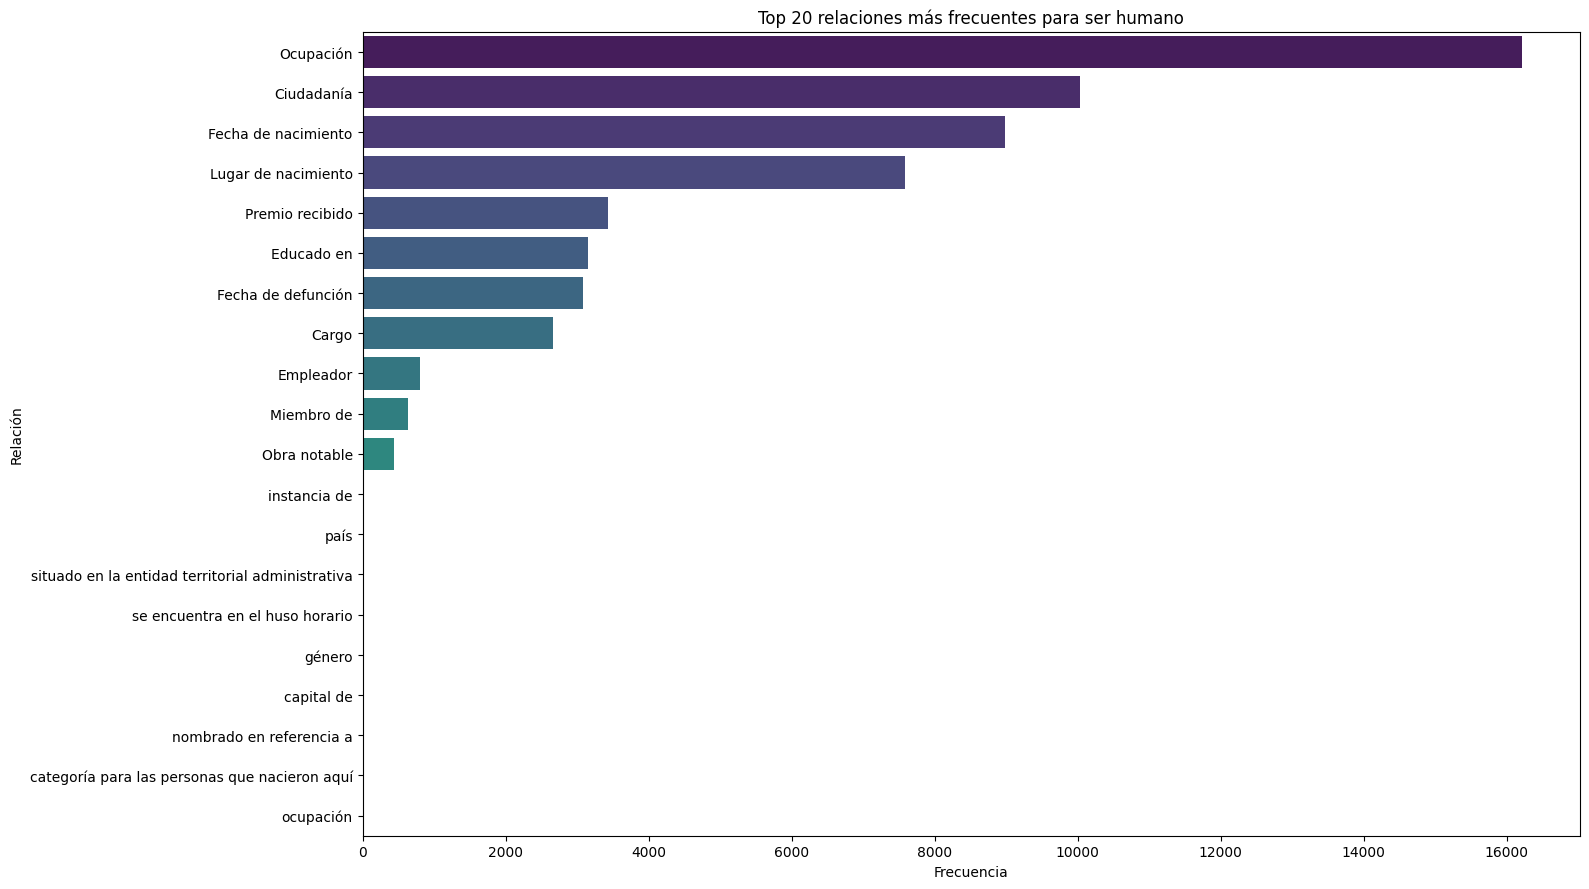

In [6]:
human_relation_counts = merged_df[merged_df['tipo_entidad'] == "ser humano"]
human_relation_counts = human_relation_counts['relacion'].value_counts().reset_index()
plot_relations(human_relation_counts, title_suffix='ser humano')

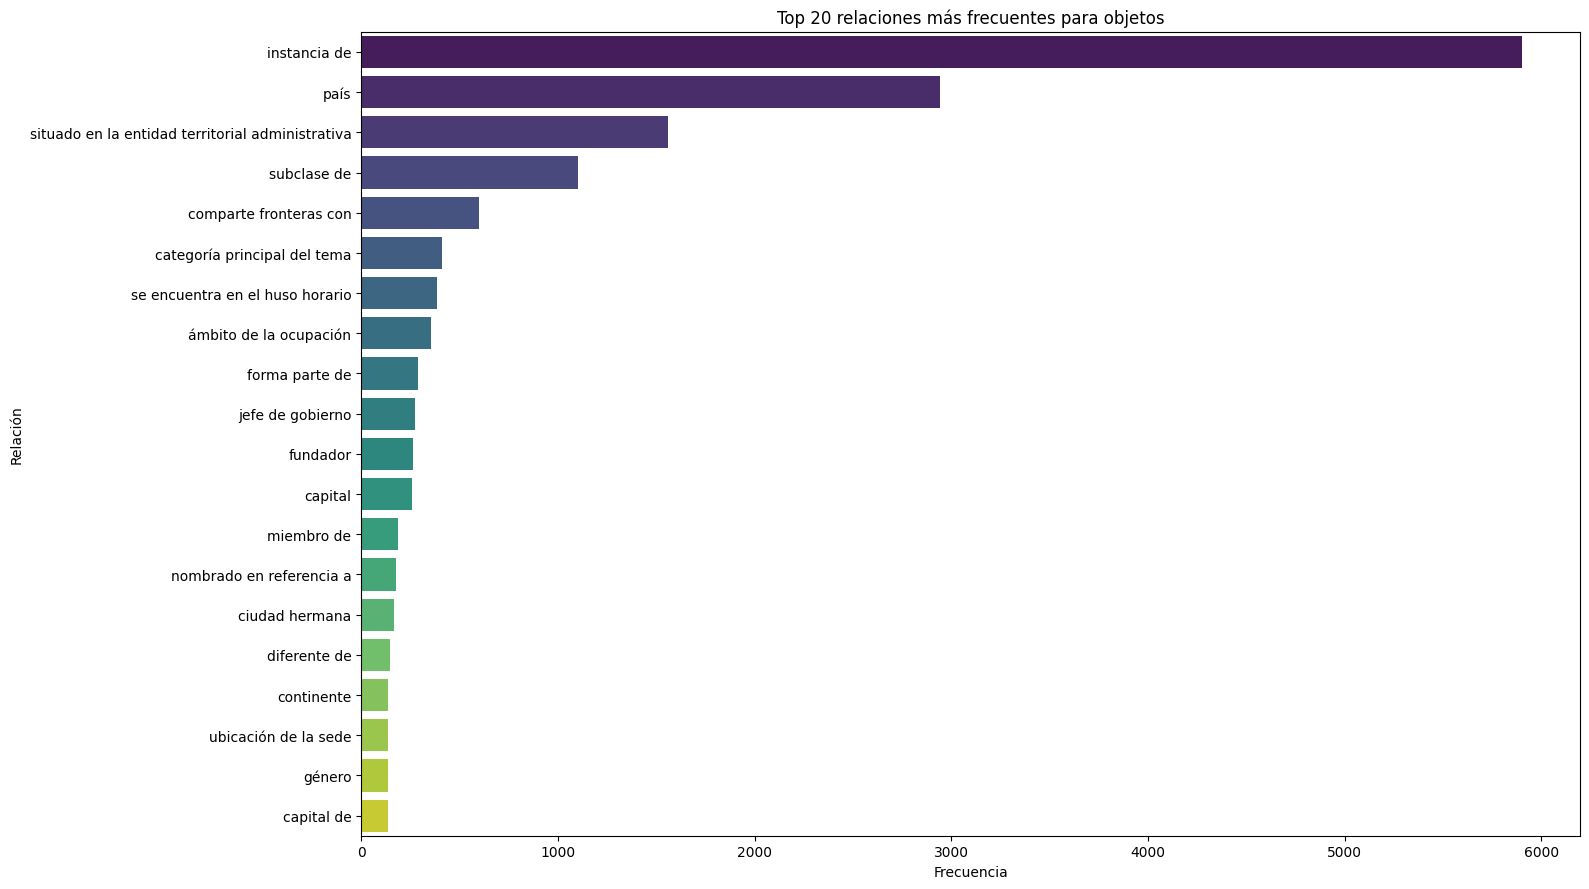

In [7]:
obj_relation_counts = merged_df[merged_df['tipo_entidad'] != "ser humano"]
obj_relation_counts = obj_relation_counts['relacion'].value_counts().reset_index()
plot_relations(obj_relation_counts, title_suffix='objetos')

### 2) Relaciones promedio por entidad

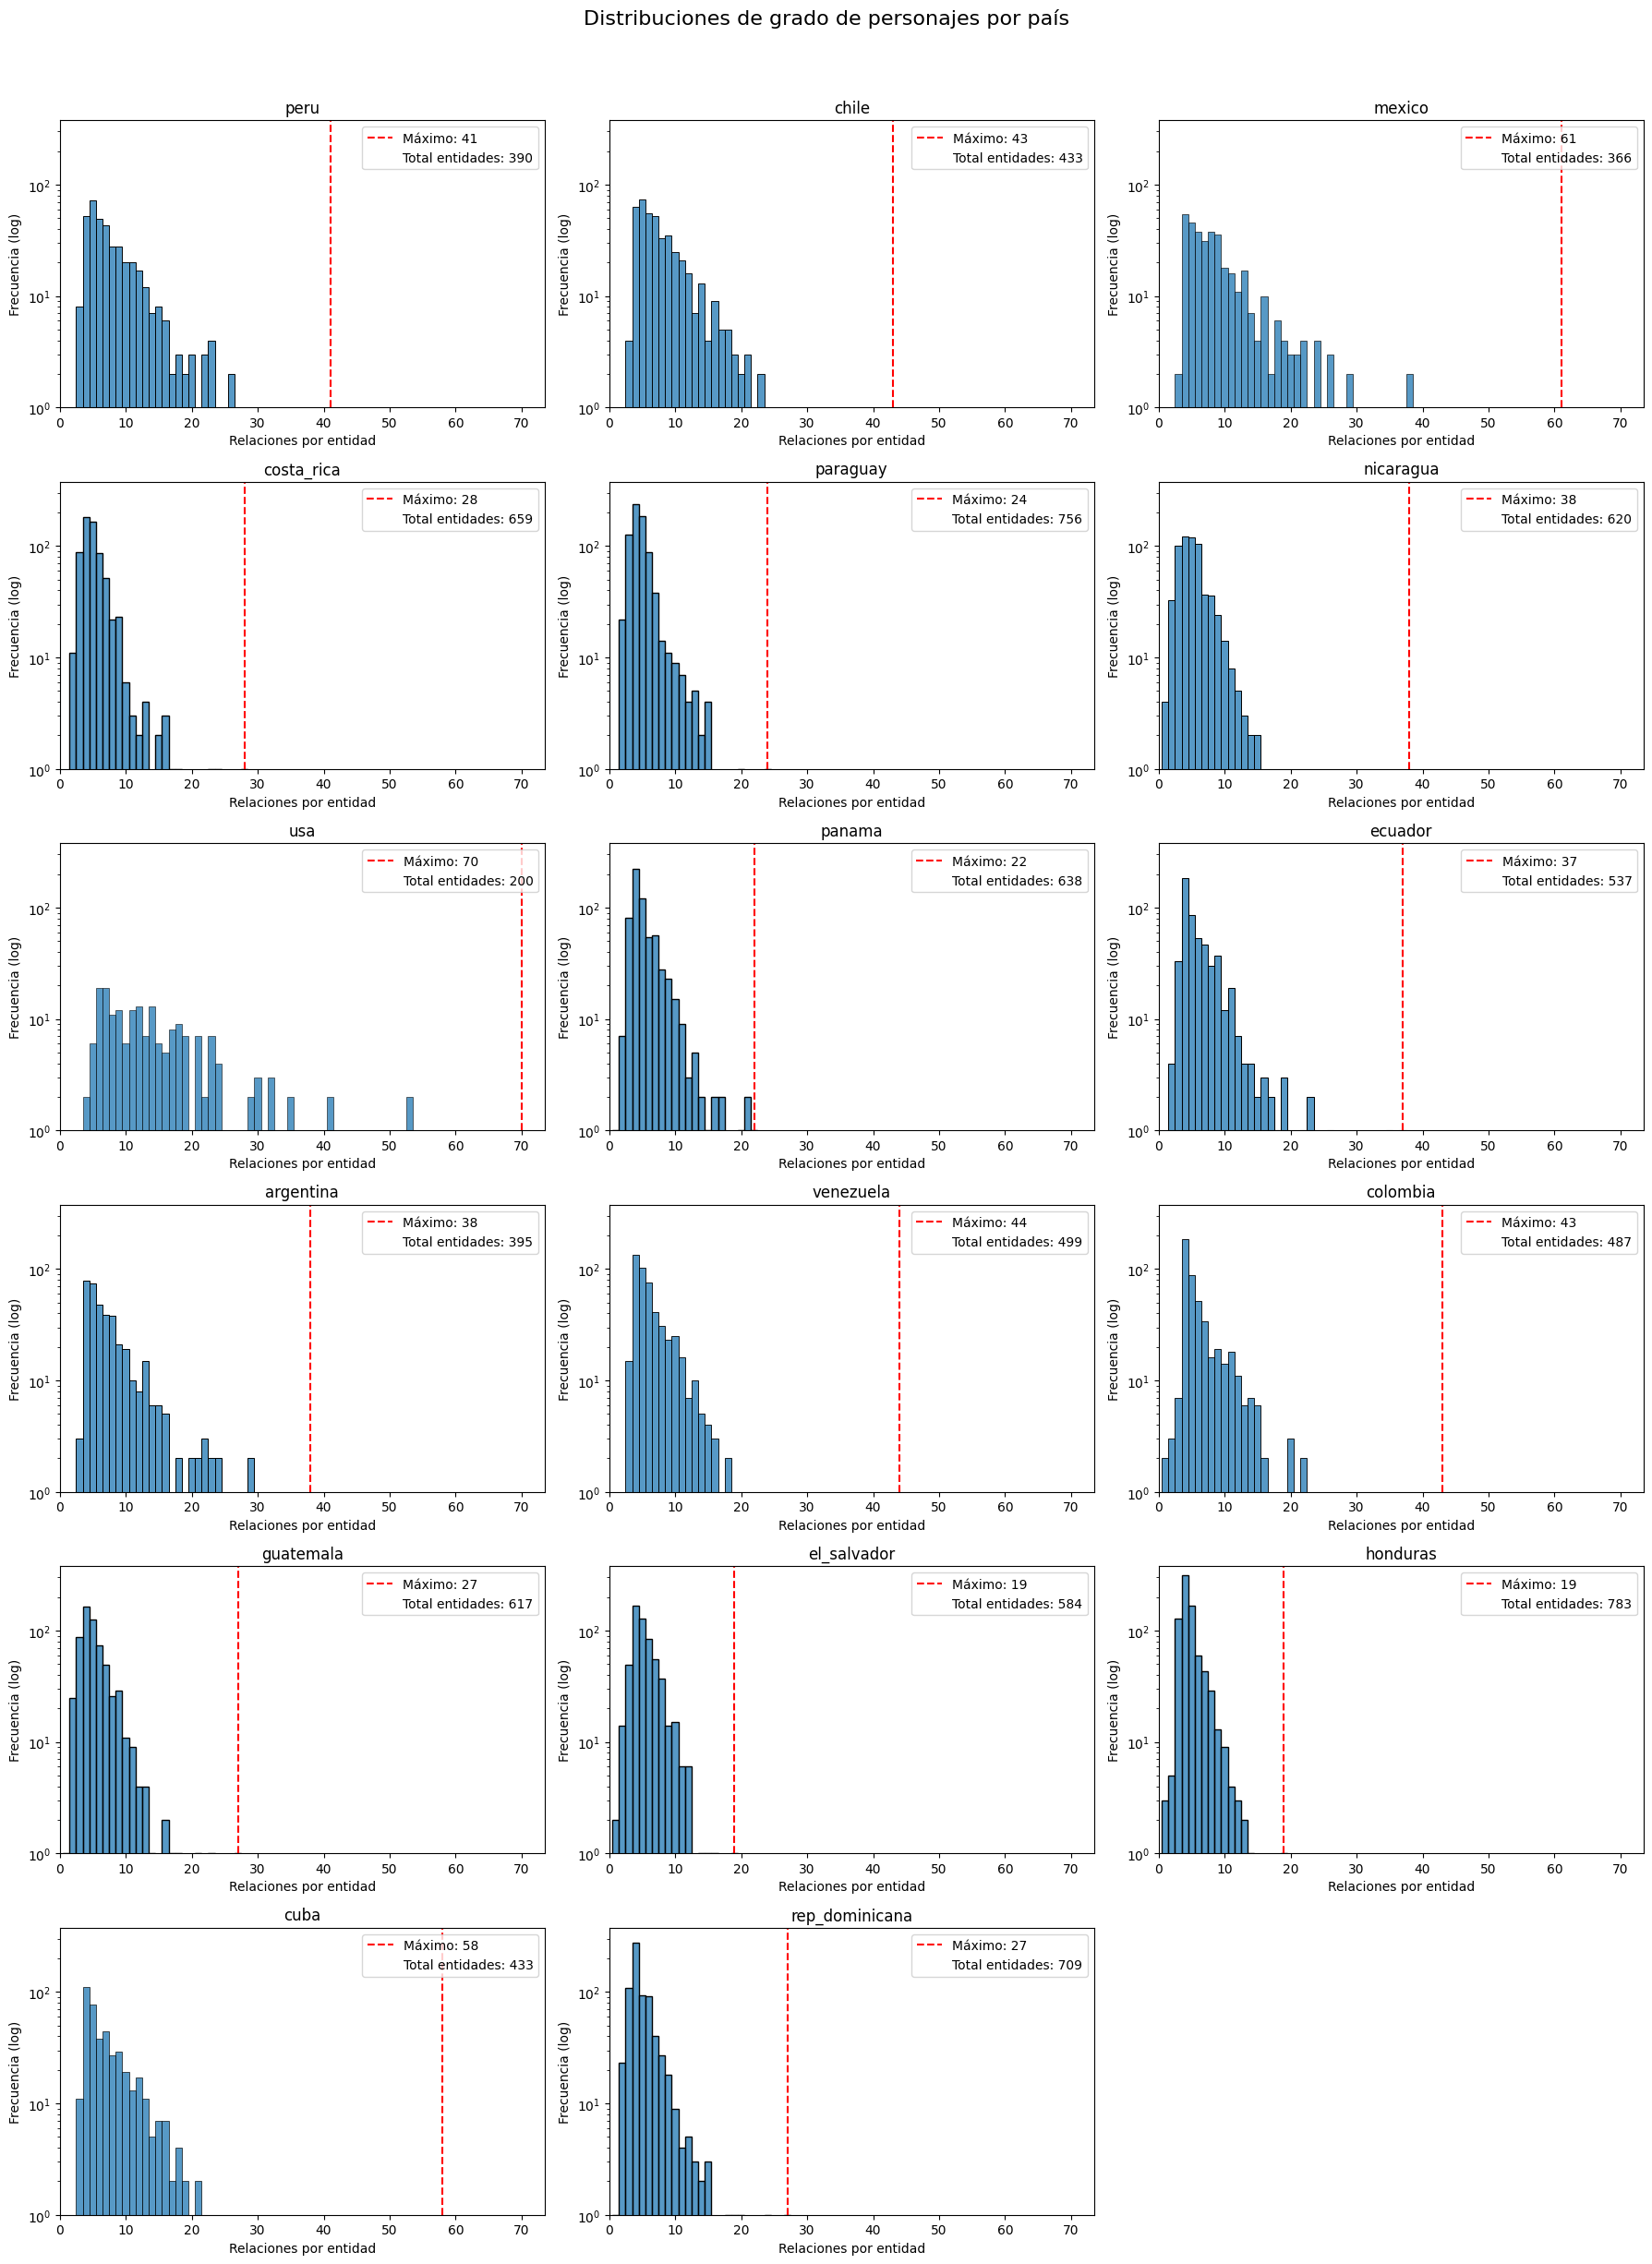

In [8]:
def plot_entity_degree_distributions(df_dict, suptitle):
    total_files = len(df_dict)
    max_x = 0
    max_y = 0
    data_dict = {}

    # Precalcula grados por archivo y máximos globales
    for country, df in df_dict.items():
        entity_degrees = df['entidad'].value_counts()
        data_dict[country] = entity_degrees
        max_x = max(max_x, entity_degrees.max())
        max_y = max(max_y, entity_degrees.value_counts().max())

    cols = 3 if total_files >= 3 else total_files
    rows = math.ceil(total_files / cols) if total_files > 0 else 1
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if total_files > 1 else [axes]

    for i, country in enumerate(df_dict.keys()):
        series = len(data_dict[country])
        max_val = max(data_dict[country])
        sns.histplot(data_dict[country], bins=range(0, max_x + 2), kde=False, ax=axes[i], discrete=True,)
        axes[i].axvline(x=max_val, color='r', linestyle='--', linewidth=1.5, label='Media')
        axes[i].legend([f'Total entidades: {series}'], loc='upper right')
        axes[i].set_xmargin(0)
        axes[i].set_xlim(0, max_x * 1.05)
        axes[i].set_yscale('log')
        axes[i].set_ylim(1, max_y * 1.2)
        axes[i].set_xlabel('Relaciones por entidad')
        axes[i].set_ylabel('Frecuencia (log)')
        axes[i].set_title(country.replace('.csv', ''))
        total_handle = Patch(facecolor='none', edgecolor='none',
                            label=f'Total entidades: {series}')

        axes[i].legend(handles=[Line2D([], [], color='r', linestyle='--', label=f'Máximo: {max_val}'), total_handle], loc='upper right')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(suptitle, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
plot_entity_degree_distributions(personajes_por_pais, "Distribuciones de grado de personajes por país")

In [9]:
# Muchas relaciones poco relevantes
df_cuba = personajes_por_pais['cuba']
df_cuba[df_cuba['entidad'] == 'Fidel Castro'].tail(10)

,entidad,relacion,objeto,source_file,tipo_entidad
3000,Fidel Castro,Premio recibido,collar de la Orden del León Blanco,cuba,ser humano
3001,Fidel Castro,Premio recibido,Emblema de la República,cuba,ser humano
3002,Fidel Castro,Premio recibido,"Orden del Príncipe Yaroslav el Sabio, 1° grado",cuba,ser humano
3003,Fidel Castro,Premio recibido,Orden al Mérito de primera clase,cuba,ser humano
3004,Fidel Castro,Premio recibido,Banda de la Orden Mexicana del Águila Azteca,cuba,ser humano
3005,Fidel Castro,Premio recibido,doctor honoris causa de la Universidad Naciona...,cuba,ser humano
3006,Fidel Castro,Premio recibido,Order of the Yugoslavian Great Star,cuba,ser humano
3007,Fidel Castro,Premio recibido,Q109986273,cuba,ser humano
3008,Fidel Castro,Premio recibido,Grand Star of People's Friendship,cuba,ser humano
3009,Fidel Castro,Premio recibido,"Order of Eduardo Mondlane, 1st class",cuba,ser humano


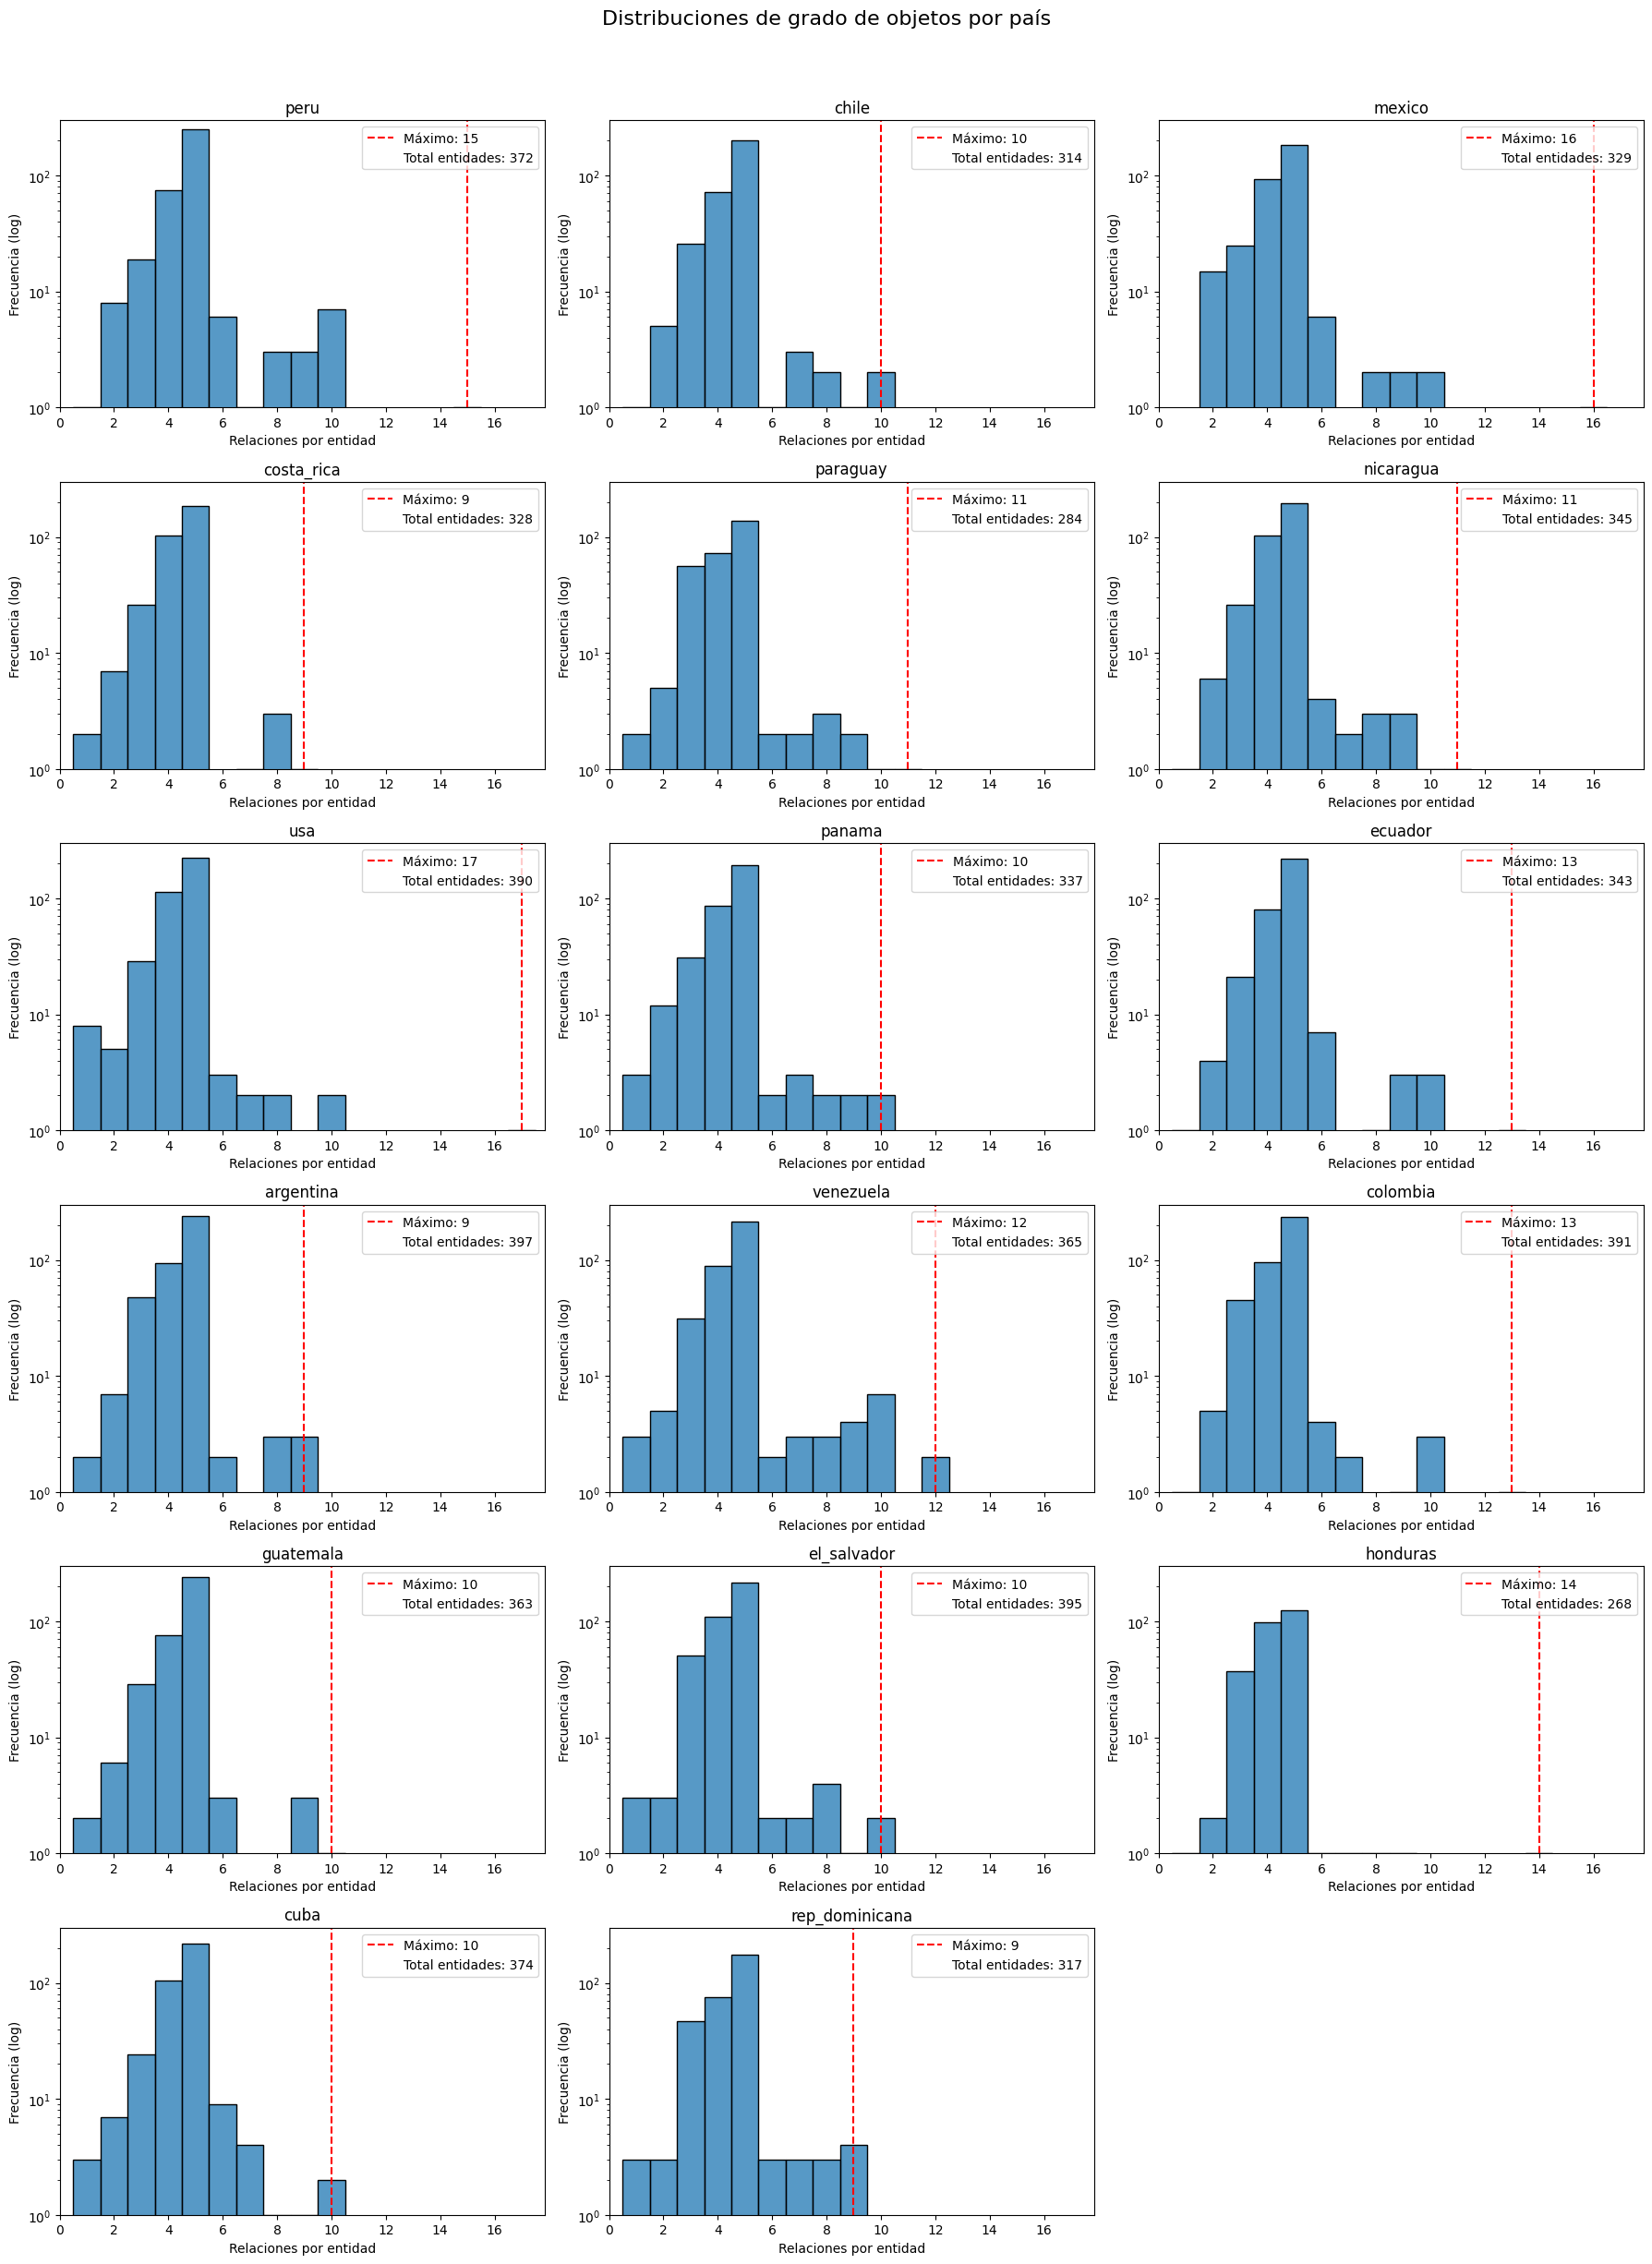

In [10]:
plot_entity_degree_distributions(objetos_por_pais, "Distribuciones de grado de objetos por país")

In [11]:
a =merged_df[merged_df['tipo_entidad'].apply(lambda x: isinstance(x, float))]
a

,entidad,relacion,objeto,source_file,tipo_entidad
7352,Academia Politécnica Militar,país,Chile,chile,NaN
24425,"Unidad Educativa ""Bolívar""",país,Ecuador,ecuador,NaN
29430,Barra de Santiago,país,El Salvador,el_salvador,NaN
29431,Barra de Santiago,situado en la entidad territorial administrativa,Jujutla,el_salvador,NaN
31622,Q135987716,Ocupación,empresario,el_salvador,NaN
...,...,...,...,...,...
70305,Q4030,Miembro de,Duke Ellington and his Washingtonians,usa,NaN
70306,Q4030,Miembro de,The Oscar Pettiford Quartet,usa,NaN
70319,Q4030,Premio recibido,German Film Award for best original music,usa,NaN
70320,Q4030,Premio recibido,Spingarn Medal,usa,NaN
